In [2]:
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

datetime(year=2021, month=7, day=4)

movies_df = pd.read_csv("Datasets/clean_movies.csv")
genres_df = pd.read_csv("Datasets/clean_genres.csv")
production_df = pd.read_csv("Datasets/clean_production.csv")

In [3]:
movies_df

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,keywords,movie_text
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0,"[{'id': 931, 'name': 'jealousy'}, {'id': 4290,...",animation comedy family jealousy toy boy frien...
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0,"[{'id': 10090, 'name': 'board game'}, {'id': 1...",adventure fantasy family roll the dice and unl...
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0,"[{'id': 1495, 'name': 'fishing'}, {'id': 12392...",romance comedy still yelling. still fighting. ...
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0,"[{'id': 818, 'name': 'based on novel'}, {'id':...",comedy drama romance friends are the people wh...
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0,"[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n...",comedy just when his world is back to normal.....
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46477,False,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n...",http://www.imdb.com/title/tt6209470/,439050,tt6209470,fa,رگ خواب,Rising and falling between a man and woman.,...,90.0,"[{'iso_639_1': 'fa', 'name': 'فارسی'}]",Released,Rising and falling between a man and woman,Subdue,False,4.0,1.0,"[{'id': 10703, 'name': 'tragic love'}]",drama family rising and falling between a man ...
46478,False,NaN,0,"[{'id': 18, 'name': 'Drama'}]",NaN,111109,tt2028550,tl,Siglo ng Pagluluwal,An artist struggles to finish his work while a...,...,360.0,"[{'iso_639_1': 'tl', 'name': ''}]",Released,NaN,Century of Birthing,False,9.0,3.0,"[{'id': 2679, 'name': 'artist'}, {'id': 14531,...",drama artist play pinoy an artist struggles to...
46479,False,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 18, 'nam...",NaN,67758,tt0303758,en,Betrayal,"When one of her hits goes wrong, a professiona...",...,90.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,A deadly game of wits.,Betrayal,False,3.8,6.0,[],action drama thriller a deadly game of wits. w...
46480,False,"{'id': 312977, 'name': 'Iron Sky Collection', ...",18000000,"[{'id': 28, 'name': 'Action'}, {'id': 35, 'nam...",http://www.ironsky.net/,302349,tt3038708,en,Iron Sky: The Coming Race,"Twenty years after the events of Iron Sky, the...",...,0.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Post Production,NaN,Iron Sky: The Coming Race,False,0.0,0.0,"[{'id': 2652, 'name': 'nazis'}, {'id': 226448,...",action comedy fantasy science fiction nazis vr...


In [4]:
movies_df['release_date'] = pd.to_datetime(movies_df['release_date'])

oldest_movie = movies_df.loc[movies_df['release_date'].idxmin()]
newest_movie = movies_df.loc[movies_df['release_date'].idxmax()]

print(f"Oldest Movie: {oldest_movie['original_title']} ({oldest_movie['release_date']})")
print(f"Newest Movie: {newest_movie['original_title']} ({newest_movie['release_date']})")

movies_df['month'] = movies_df['release_date'].dt.month

/var/folders/km/h432qbx55ljb5h2m9n7_s65c0000gn/T/ipykernel_29544/2277734729.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  movies_df['release_date'] = pd.to_datetime(movies_df['release_date'])


Oldest Movie: Passage de Venus (1874-12-09 00:00:00)
Newest Movie: Ирония судьбы, или С легким паром! (2075-12-31 00:00:00)


In [5]:
#movies from the future?!  Let's remove that
movies_df = movies_df[movies_df['release_date'] <= pd.Timestamp.now()]

oldest_movie = movies_df.loc[movies_df['release_date'].idxmin()]
newest_movie = movies_df.loc[movies_df['release_date'].idxmax()]

print(f"Oldest Movie: {oldest_movie['original_title']} ({oldest_movie['release_date']})")
print(f"Newest Movie: {newest_movie['original_title']} ({newest_movie['release_date']})")

#this is a mess.  For Heaven's Sake was released in 1926.
#for the sake of time and sanity, I am calling this out of scope for this project. For my time questions I am only looking at the month anyway


Oldest Movie: Passage de Venus (1874-12-09 00:00:00)
Newest Movie: For Heaven's Sake (2026-04-05 00:00:00)


In [6]:
#pulled in from the final project to play around with here
movies_df['profit'] = movies_df['revenue'] - movies_df['budget']
movies_df = movies_df[(movies_df['popularity'] != 0) & (movies_df['vote_count'] > 10)]
movies_df = movies_df[(movies_df['budget'] > 500) & (movies_df['revenue'] > 500)]

/var/folders/km/h432qbx55ljb5h2m9n7_s65c0000gn/T/ipykernel_29544/3182457080.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies_df['profit'] = movies_df['revenue'] - movies_df['budget']


In [ ]:
# for the power point

# #convert to datetime
# movies_df['release_date'] = pd.to_datetime(movies_df['release_date'])

# #lower threshold
# movies_df = movies_df[(movies_df['popularity'] != 0) & (movies_df['vote_count'] > 10)]

# #Is there a connection between the release date month and profit / popularity
# monthly_pop = movies_df.groupby('month')[['popularity']].mean()
# print(monthly_pop.sort_values(by='popularity', ascending=True))

# monthly_rev = movies_df.groupby('month')[['profit']].mean()
# print(monthly_rev.sort_values(by='profit', ascending=True))


       popularity
month            
1.0      8.212113
9.0      9.169379
8.0      9.474583
2.0      9.578906
12.0    10.161310
4.0     10.327111
3.0     10.574838
11.0    10.687721
10.0    11.050936
7.0     11.245021
5.0     11.547770
6.0     13.241386
             profit
month              
1.0    2.637899e+07
9.0    2.640238e+07
8.0    3.649964e+07
10.0   4.319623e+07
2.0    4.713387e+07
3.0    5.810871e+07
4.0    5.967715e+07
7.0    8.474032e+07
12.0   8.804498e+07
11.0   9.124933e+07
5.0    1.072725e+08
6.0    1.213386e+08


In [8]:
#connection between month (release date) and profit / popularity

monthly_pop = movies_df.groupby('month')[['popularity']].mean()
print(monthly_pop.sort_values(by='popularity', ascending=True))

monthly_rev = movies_df.groupby('month')[['profit']].mean()
print(monthly_rev.sort_values(by='profit', ascending=True))

# Movies that are released in January tend to be ranked less favorably and are less profitable.  Although I am questioning this because of the junk data that I have...

       popularity
month            
1.0      8.212113
9.0      9.169379
8.0      9.474583
2.0      9.578906
12.0    10.161310
4.0     10.327111
3.0     10.574838
11.0    10.687721
10.0    11.050936
7.0     11.245021
5.0     11.547770
6.0     13.241386
             profit
month              
1.0    2.637899e+07
9.0    2.640238e+07
8.0    3.649964e+07
10.0   4.319623e+07
2.0    4.713387e+07
3.0    5.810871e+07
4.0    5.967715e+07
7.0    8.474032e+07
12.0   8.804498e+07
11.0   9.124933e+07
5.0    1.072725e+08
6.0    1.213386e+08


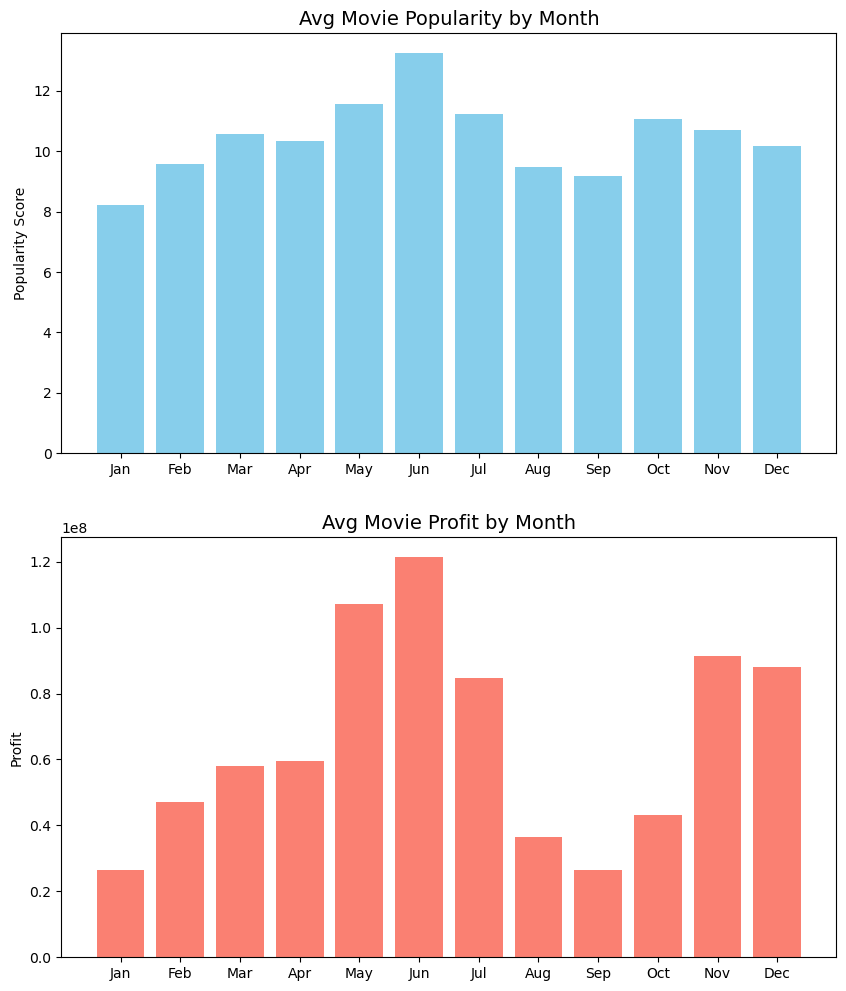

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 12))

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.subplot(2, 1, 1)
plt.bar(monthly_pop.index, monthly_pop['popularity'], color='skyblue')
plt.title('Avg Movie Popularity by Month', fontsize=14)
plt.xticks(range(1, 13), month_labels)
plt.ylabel('Popularity Score')

plt.subplot(2, 1, 2)
plt.bar(monthly_rev.index, monthly_rev['profit'], color='salmon')
plt.title('Avg Movie Profit by Month', fontsize=14)
plt.xticks(range(1, 13), month_labels)
plt.ylabel('Profit')

plt.show()


In [10]:
#worst movies and when they were released
least_popular= movies_df.sort_values('popularity').head(1000)
least_profitable = movies_df.sort_values('profit').head(1000)

overlap = least_popular[least_popular['id'].isin(least_profitable['id'])]

least_popular_by_month = overlap['month'].value_counts().sort_index()

print(least_popular_by_month)

month
1.0     17
2.0     23
3.0     22
4.0     22
5.0     18
6.0     22
7.0     13
8.0     23
9.0     46
10.0    32
11.0    31
12.0    27
Name: count, dtype: int64


In [11]:
overlap

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,status,tagline,title,video,vote_average,vote_count,keywords,movie_text,month,profit
4088,False,"{'id': 9743, 'name': 'The Hannibal Lecter Anth...",15000000,"[{'id': 80, 'name': 'Crime'}, {'id': 27, 'name...",NaN,11454,tt0091474,en,Manhunter,"FBI Agent Will Graham, who retired after catch...",...,Released,Enter the mind of a serial killer… you may nev...,Manhunter,False,6.8,340.0,"[{'id': 1465, 'name': 'loss of family'}, {'id'...",crime horror thriller enter the mind of a seri...,8.0,-6379071.0
20973,False,NaN,58000000,"[{'id': 35, 'name': 'Comedy'}]",http://www.theinternshipmovie.com/,116741,tt2234155,en,The Internship,Two recently laid-off men in their 40s try to ...,...,Released,Hiring them was a brilliant mistake.,The Internship,False,6.1,1691.0,"[{'id': 3489, 'name': 'job interview'}, {'id':...",comedy hiring them was a brilliant mistake. jo...,6.0,-14000000.0
40961,False,NaN,15000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 16, '...",NaN,32147,tt0090065,en,Starchaser: The Legend of Orin,"Set on the subterranean Mine-World, a band of ...",...,Released,He alone has the power,Starchaser: The Legend of Orin,False,6.8,11.0,[],adventure animation family science fiction he ...,1.0,-11639200.0
11814,False,NaN,8000000,"[{'id': 18, 'name': 'Drama'}]",http://www.northernstars.ca/titles/2005/mauric...,49081,tt0460505,fr,Maurice Richard,"In the late 1930s, a young machinist named Mau...",...,Released,NaN,The Rocket: The Legend of Rocket Richard,False,6.1,17.0,"[{'id': 3356, 'name': 'quebec'}, {'id': 6075, ...",drama quebec sport ice hockey hockey player mo...,10.0,-5980991.0
3126,False,NaN,36000000,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name...",NaN,75531,tt0141399,de,Isn't She Great,An unsuccessful over-the-top actress becomes a...,...,Released,Talent Isn't Everything...,Isn't She Great,False,4.6,14.0,"[{'id': 1646, 'name': 'autism'}]",drama comedy talent isn t everything... autism...,1.0,-32996704.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2442,False,NaN,13000000,"[{'id': 18, 'name': 'Drama'}, {'id': 27, 'name...",NaN,9540,tt0094964,en,Dead Ringers,"Elliot, a successful gynecologist, works at th...",...,Released,Two bodies. Two minds. One soul.,Dead Ringers,False,7.0,176.0,"[{'id': 428, 'name': 'nurse'}, {'id': 572, 'na...",drama horror thriller two bodies. two minds. o...,9.0,-4961492.0
5450,False,NaN,9000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,9685,tt0280760,en,Igby Goes Down,A young man's peculiar upbringing renders him ...,...,Released,Insanity is relative.,Igby Goes Down,False,6.5,95.0,"[{'id': 494, 'name': 'father son relationship'...",comedy drama insanity is relative. father son ...,9.0,-4222535.0
10723,False,NaN,45000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 35, '...",NaN,17379,tt0408985,en,Last Holiday,"After she's diagnosed with a terminal illness,...",...,Released,She always thought she was somebody special......,Last Holiday,False,6.4,123.0,[],adventure comedy drama she always thought she ...,1.0,-6600039.0
22418,False,NaN,7200000,"[{'id': 12, 'name': 'Adventure'}, {'id': 18, '...",NaN,14499,tt0093543,en,Mio min Mio,"They're two best friends, a million miles from...",...,Released,"They're two best friends, a million miles from...",Mio in the Land of Faraway,False,6.3,23.0,"[{'id': 5202, 'name': 'boy'}, {'id': 6054, 'na...",adventure drama fantasy family mystery they re...,7.0,-4900000.0


In [ ]:
#questions for another time and with cleaner data...
#has popularity risen, fallen or stayed static over time?

In [13]:
#connection between genre and profit / popularity

In [14]:
#connection between production company and profit / popularity